# Marginal smoothing with separate invariant parameters

The workflow constructs a `MarginalApproximator`: an invariant continuous head conditioned on the pooled observation encoding, and a varying continuous head conditioned on that encoding and the invariant parameters. Invariants are never tiled as training targets. Sampling draws invariants first, then one trajectory for each draw.

This benchmark retains 100 trials, 10,000 training datasets, 50 epochs, and batch size 32. The final cells retrain the previous tiled marginal approach on the same data to compare posterior recovery and 95% interval coverage. The two total training losses use different objectives and should not be compared directly.

The invariant sigma parameters are positive. Their adapter uses log coordinates and their head uses a spline flow. Set `REUSE_SAVED_BENCHMARK=False` to regenerate data and retrain the legacy baseline.


In [1]:
import os
from pathlib import Path

os.environ.setdefault("KERAS_BACKEND", "jax")

import bayesflow as bf
import jax
import keras
import numpy as np
import pandas as pd
import superstats as sup

print("Backend:", keras.backend.backend(), "Devices:", jax.devices())


INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/Users/lschumacher/.local/share/uv/python/cpython-3.13.14-macos-aarch64-none/lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)
INFO:bayesflow:Using backend 'jax'


Backend: jax Devices: [CpuDevice(id=0)]


## Constants

In [2]:
SEED = 2026
NUM_STEPS = 100
NUM_TRAIN = 10_000
NUM_VALIDATION = 100
NUM_TEST = 100
NUM_SAMPLES = 300
NUM_EPOCHS = 50
BATCH_SIZE = 32
RUN_LEGACY_COMPARISON = True
REUSE_SAVED_BENCHMARK = True
ARTIFACT_DIR = Path("checkpoints/benchmark_marginal")

keras.utils.set_random_seed(SEED)


## Prior and generative model

In [3]:
joint_prior = sup.prior.JointPrior(
    v=sup.transition.RandomWalk(
        sigma=sup.prior.Prior(dist="halfnormal", scale=0.1),
        delta=0.0,
        initial_prior=sup.prior.Prior(dist="normal", loc=-1.5, scale=0.5),
    ),
    a=sup.transition.RandomWalk(
        sigma=sup.prior.Prior(dist="halfnormal", scale=0.1),
        delta=0.0,
        initial_prior=sup.prior.Prior(dist="normal", loc=0.0, scale=0.5),
    ),
    tau=sup.transition.RandomWalk(
        sigma=sup.prior.Prior(dist="halfnormal", scale=0.1),
        delta=0.0,
        initial_prior=sup.prior.Prior(dist="normal", loc=-1.5, scale=0.5),
    ),
    bias=0.5,
)

generative_model = sup.Model(
    prior=joint_prior,
    simulator=sup.simulation.sample_ddm,
    link_function={
        "v": sup.LinkFunction(bounds=(0.0, 6.0)),
        "a": sup.LinkFunction(bounds=(0.0, 4.0)),
        "tau": sup.LinkFunction(bounds=(0.0, 2.0)),
    },
    missing="random",
)
print("Varying:", generative_model.local_keys)
print("Invariant:", generative_model.hyper_keys + generative_model.shared_keys)


Varying: ['v', 'a', 'tau']
Invariant: ['v_sigma', 'a_sigma', 'tau_sigma']


## Workflow

In [5]:
def make_summary_network():
    return bf.networks.RecurrentNetwork(
        time_embed_dim=16,
        return_sequences=True,
        bidirectional=True,
    )


workflow = sup.Workflow(
    model=generative_model,
    adapter=sup.Workflow.default_adapter(generative_model).log("invariant_variables"),
    embedding_network=make_summary_network(),
    varying_inference_network=bf.networks.CouplingFlow(),
    invariant_inference_network=bf.networks.CouplingFlow(
        depth=3, transform="spline", subnet_kwargs={"widths": (128, 128)}
    ),
)
assert isinstance(workflow.approximator, sup.MarginalApproximator)
assert workflow.approximator.mode == "smoothing"


## Untiled training targets

In [8]:
reuse_saved_data = REUSE_SAVED_BENCHMARK and all(
    (ARTIFACT_DIR / name).exists()
    for name in ["training_data.npz", "validation_data.npz", "test_data.npz", "legacy.keras", "legacy_samples.npz"]
)


def load_arrays(name):
    with np.load(ARTIFACT_DIR / f"{name}.npz") as arrays:
        return dict(arrays)


if reuse_saved_data:
    training_data = load_arrays("training_data")
    val_data = load_arrays("validation_data")
else:
    training_data = generative_model.sample(
        NUM_TRAIN, num_steps=NUM_STEPS, tile_to_steps=False, rng=np.random.default_rng(SEED)
    )
    val_data = generative_model.sample(
        NUM_VALIDATION, num_steps=NUM_STEPS, tile_to_steps=False, rng=np.random.default_rng(SEED + 1)
    )
training_batch = workflow.adapter({key: value[:BATCH_SIZE] for key, value in training_data.items()})
print({key: value.shape for key, value in training_batch.items()})
assert training_batch["inference_variables"].shape == (BATCH_SIZE, NUM_STEPS, 3)
assert training_batch["invariant_variables"].shape == (BATCH_SIZE, 3)


{'p_missing': (32, 1), 'inference_variables': (32, 100, 3), 'invariant_variables': (32, 3), 'summary_variables': (32, 100, 4)}


In [ ]:
history = workflow.fit_offline(
    data=training_data,
    validation_data=val_data,
    epochs=NUM_EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=2,
)


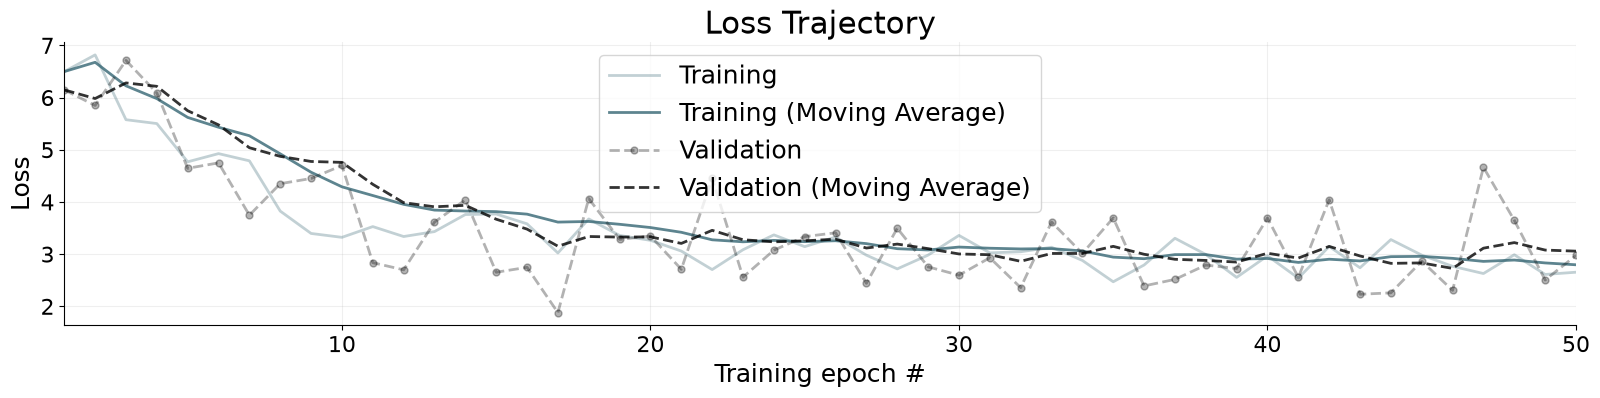

In [ ]:
fig = workflow.plot_history(workflow.history)

## Posterior verification

In [ ]:
if reuse_saved_data:
    test_data = load_arrays("test_data")
else:
    test_data = generative_model.sample(
        batch_size=NUM_TEST,
        num_steps=NUM_STEPS,
        tile_to_steps=False,
        rng=np.random.default_rng(SEED + 2),
    )
samples = workflow.sample(
    data=test_data,
    num_samples=NUM_SAMPLES,
    batch_size=8,
    seed=SEED + 3,
)
print({key: value.shape for key, value in samples.items()})
for key in generative_model.local_keys:
    assert samples[key].shape == (NUM_TEST, NUM_SAMPLES, NUM_STEPS, 1)
for key in generative_model.hyper_keys + generative_model.shared_keys:
    assert samples[key].shape == (NUM_TEST, NUM_SAMPLES, 1)
log_prob = workflow.approximator.log_prob(test_data)
assert log_prob.shape == (NUM_TEST,) and np.isfinite(log_prob).all()
print("Mean log density of complete targets:", log_prob.mean())


### Time-varying parameters

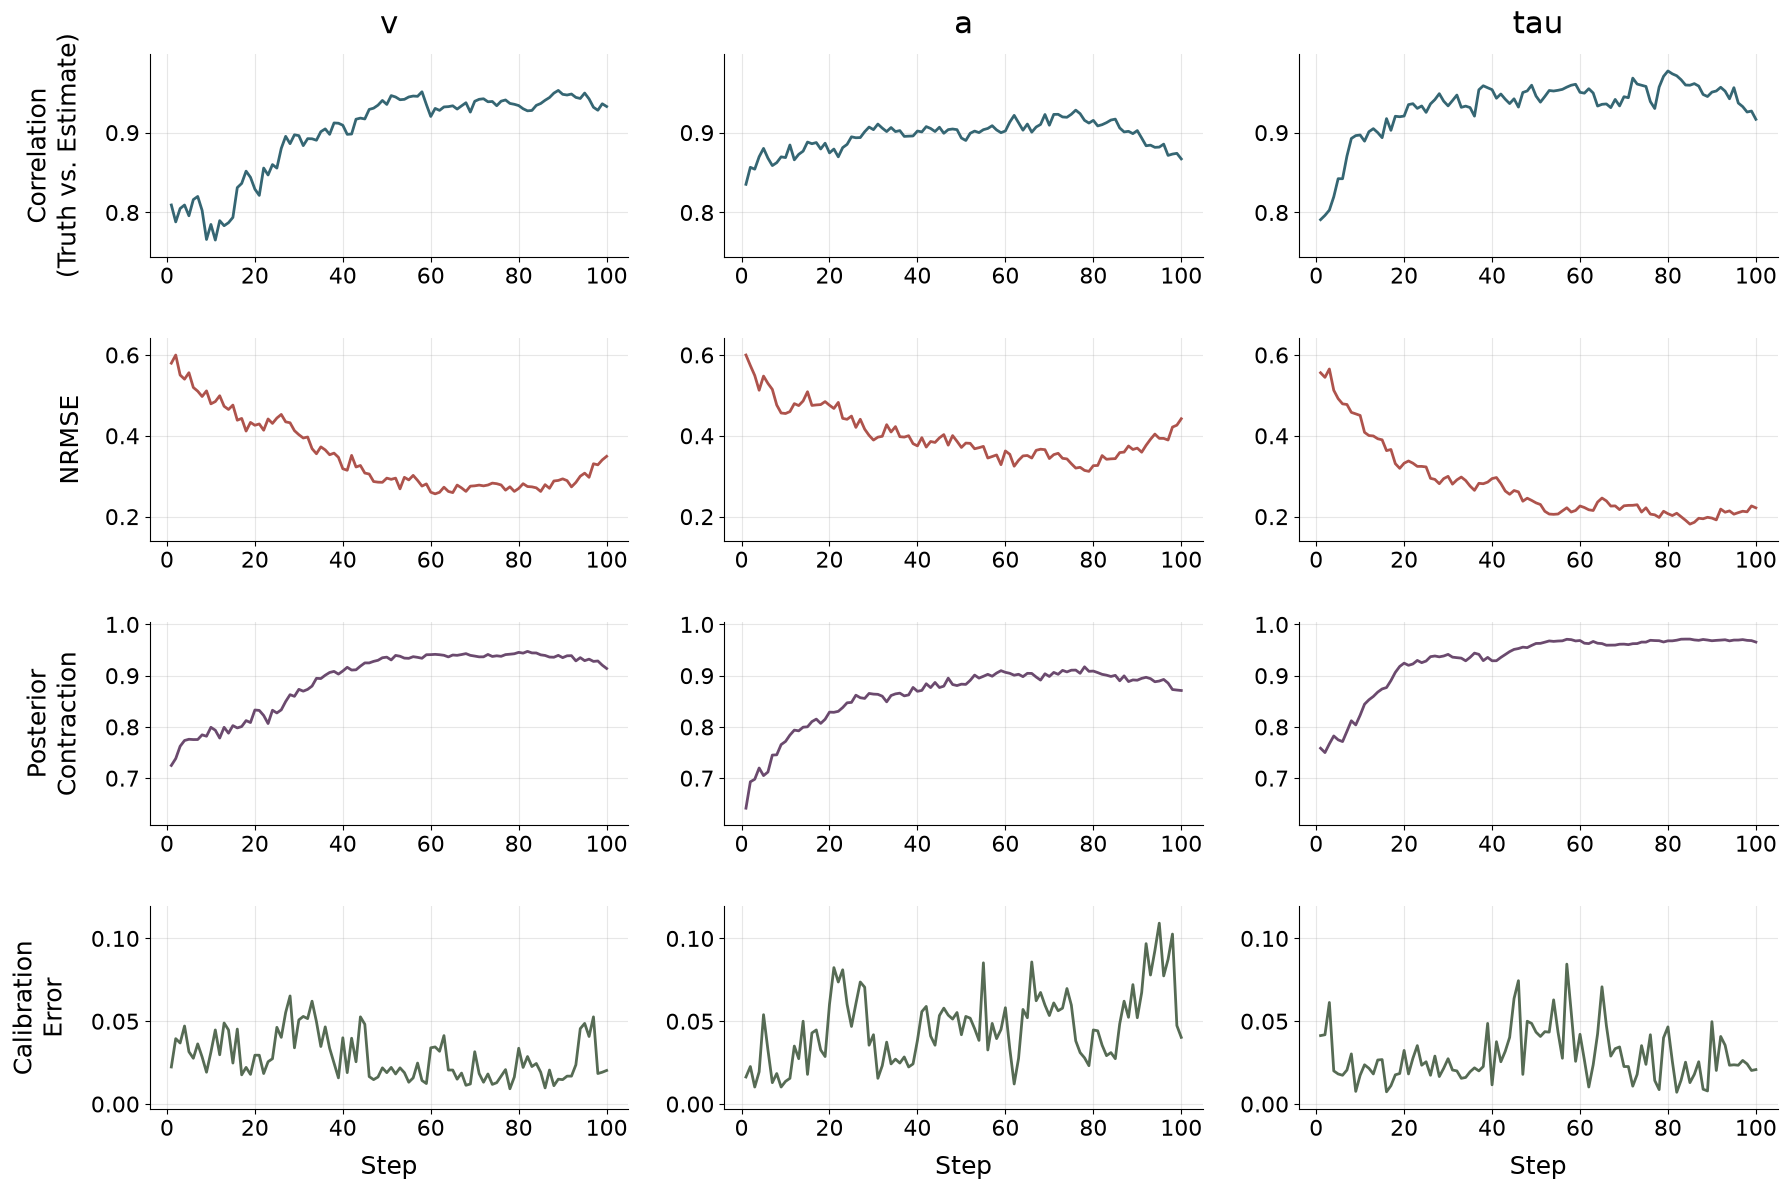

In [9]:
fig = workflow.verify_time_varying(test_data, samples)

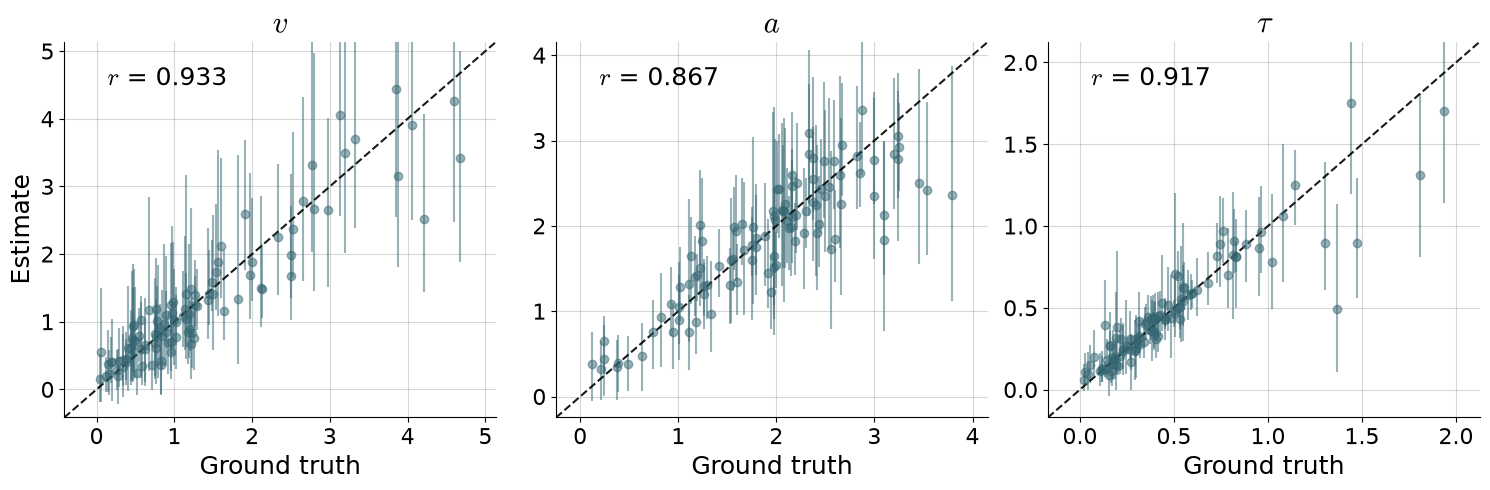

In [10]:
fig = workflow.recovery_at_steps(
    targets=test_data,
    estimates=samples,
    time_steps=NUM_STEPS - 1,
    variable_names=[r"$v$", r"$a$", r"$\tau$"],
)


### Time-invariant parameters

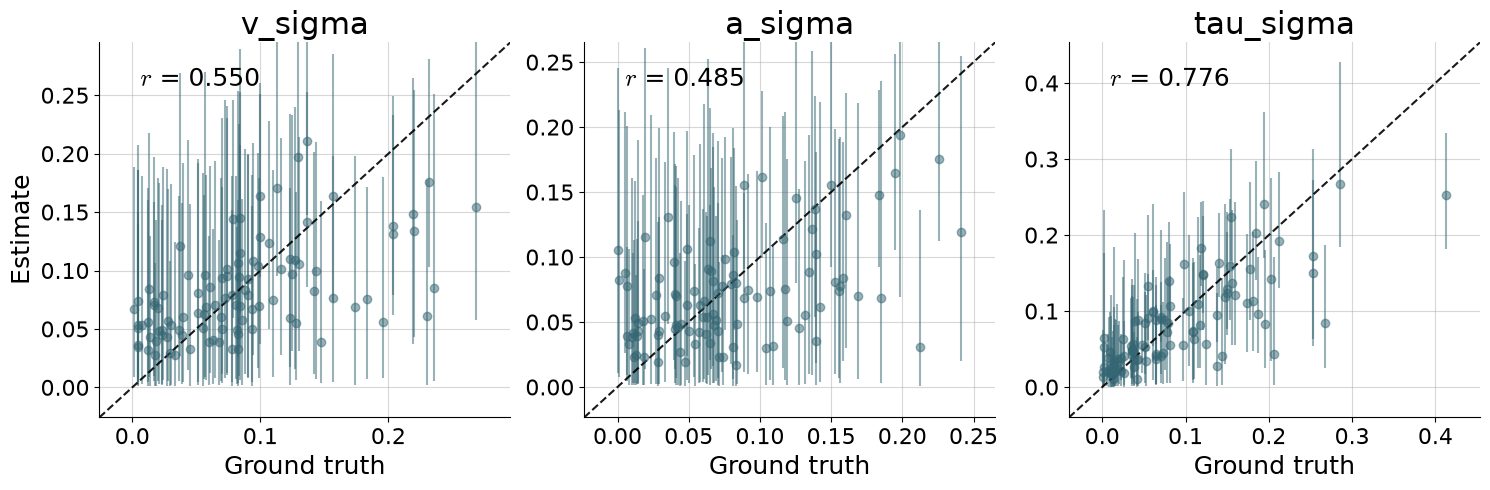

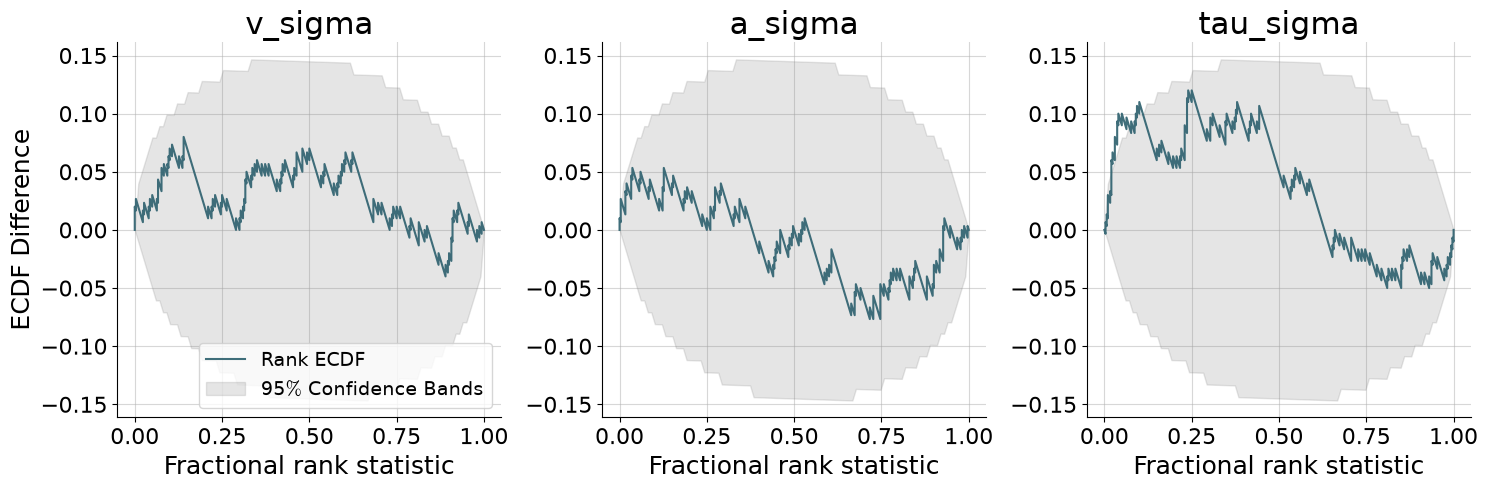

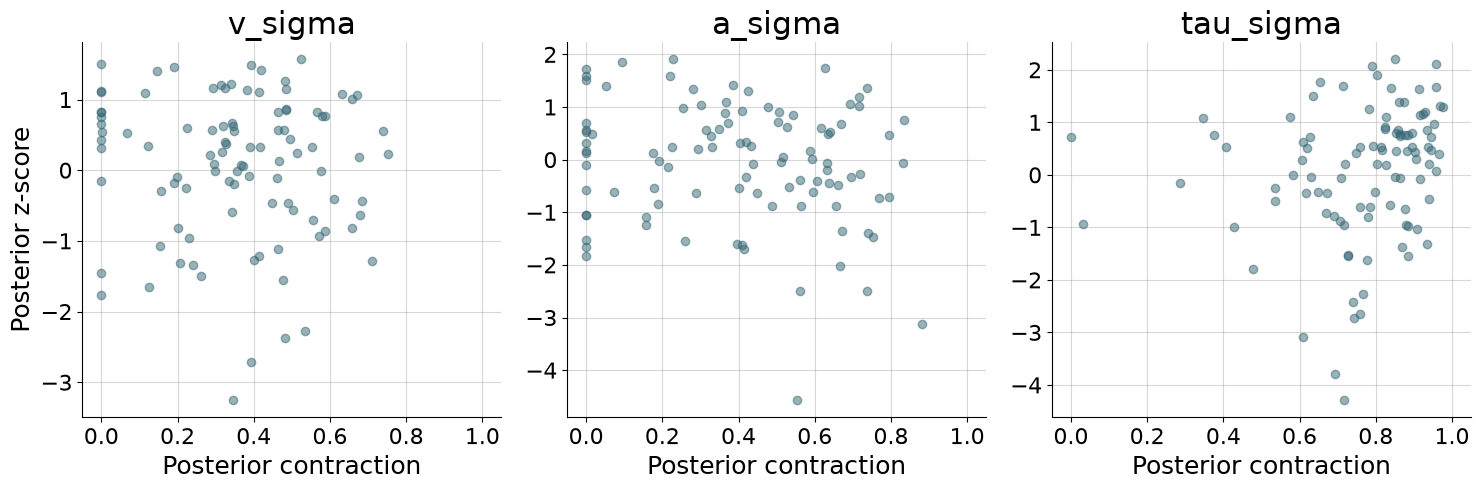

In [11]:
fig_recovery, fig_calibration, fig_contraction = workflow.verify_time_invariant(
    test_data, samples
)


## Comparison with the previous tiled marginal approach

Both models use the same observation encoder configuration, sequence coupling-flow configuration, data, optimizer schedule, epoch count, and batch size. The composite has an additional spline invariant head in log coordinates. The legacy static posterior is the mixture of its per-time posterior estimates, matching the previous invariant diagnostics; flattening the sample and time axes does not treat the repeats as additional independent ground-truth datasets.

RMSE and MAE compare posterior means with held-out parameters. Coverage is the fraction of true parameters inside central 95% posterior intervals. Normalized RMSE divides by the held-out parameter standard deviation, so parameters with different scales can be compared. This single training seed is a performance check, rather than a statistical guarantee.


In [12]:
legacy_samples = None
if RUN_LEGACY_COMPARISON:
    keras.utils.set_random_seed(SEED)
    invariant_keys = generative_model.hyper_keys + generative_model.shared_keys
    target_keys = generative_model.local_keys + invariant_keys
    summary_keys = ["time_steps", *generative_model.summary_keys, "missing_mask"]
    legacy_adapter = (
        bf.Adapter()
        .convert_dtype("float64", "float32")
        .as_time_series(summary_keys)
        .concatenate(target_keys, into="inference_variables")
        .concatenate(summary_keys, into="summary_variables")
    )

    def legacy_targets(data):
        result = dict(data)
        for key in invariant_keys:
            result[key] = np.broadcast_to(
                data[key][:, None, :], (data[key].shape[0], NUM_STEPS, data[key].shape[-1])
            )
        return result

    legacy_workflow = bf.BasicWorkflow(
        simulator=generative_model,
        adapter=legacy_adapter,
        summary_network=make_summary_network(),
        inference_network=bf.networks.CouplingFlow(),
        standardize="all",
    )
    if reuse_saved_data:
        legacy_workflow.approximator = keras.saving.load_model(ARTIFACT_DIR / "legacy.keras")
        legacy_samples = load_arrays("legacy_samples")
        print("Reused the baseline trained for", NUM_EPOCHS, "epochs on these saved datasets.")
    else:
        legacy_history = legacy_workflow.fit_offline(
            data=legacy_targets(training_data),
            validation_data=legacy_targets(val_data),
            epochs=NUM_EPOCHS,
            batch_size=BATCH_SIZE,
            verbose=2,
        )
        legacy_samples = legacy_workflow.sample(
            conditions=workflow._prepare_conditions(test_data),
            num_samples=NUM_SAMPLES,
            batch_size=8,
            seed=SEED + 3,
        )


Reused the baseline trained for 50 epochs on these saved datasets.


In [13]:
from pathlib import Path
import json

artifact_dir = ARTIFACT_DIR
artifact_dir.mkdir(parents=True, exist_ok=True)
for name, data in {
    "training_data": training_data,
    "validation_data": val_data,
    "test_data": test_data,
    "marginal_samples": samples,
}.items():
    np.savez_compressed(artifact_dir / f"{name}.npz", **data)
workflow.approximator.save(artifact_dir / "marginal.keras")
if legacy_samples is not None:
    np.savez_compressed(artifact_dir / "legacy_samples.npz", **legacy_samples)
    legacy_workflow.approximator.save(artifact_dir / "legacy.keras")
(artifact_dir / "parameters.json").write_text(json.dumps({
    "local_keys": generative_model.local_keys,
    "hyper_keys": generative_model.hyper_keys,
    "shared_keys": generative_model.shared_keys,
}, indent=2))
print("Saved models, data, and posteriors for the next joint comparison:", artifact_dir.resolve())


Saved models, data, and posteriors for the next joint comparison: /home/radevs/Desktop/Projects/superstats/checkpoints/benchmark_marginal


In [14]:
def posterior_scores(posterior, method):
    rows = []
    for key in generative_model.local_keys + generative_model.hyper_keys + generative_model.shared_keys:
        draws = posterior[key]
        target = test_data[key]
        if key not in generative_model.local_keys and draws.ndim == 4:
            draws = draws.reshape(draws.shape[0], -1, draws.shape[-1])
        estimate = draws.mean(axis=1)
        lower, upper = np.quantile(draws, [0.025, 0.975], axis=1)
        error = estimate - target
        rmse = float(np.sqrt(np.mean(error**2)))
        rows.append({
            "method": method,
            "parameter": key,
            "rmse": rmse,
            "normalized_rmse": rmse / float(target.std()),
            "mae": float(np.mean(np.abs(error))),
            "coverage_95": float(np.mean((target >= lower) & (target <= upper))),
        })
    return rows


rows = posterior_scores(samples, "separate invariants")
if legacy_samples is not None:
    rows += posterior_scores(legacy_samples, "tiled legacy")
comparison = pd.DataFrame(rows).set_index(["parameter", "method"]).sort_index()
display(comparison.round(4))
if legacy_samples is not None:
    rmse = comparison["normalized_rmse"].unstack("method")
    ratio = rmse["separate invariants"] / rmse["tiled legacy"]
    display(ratio.rename("RMSE ratio: separate / legacy").round(4))
    print("Mean normalized RMSE ratio:", ratio.mean())

comparison.to_csv(ARTIFACT_DIR / "posterior_comparison.csv")


rmse  normalized_rmse     mae  coverage_95
parameter method                                                           
a         separate invariants  0.2909           0.4399  0.2167       0.9122
          tiled legacy         0.2883           0.4360  0.2128       0.9162
a_sigma   separate invariants  0.0500           0.8907  0.0389       0.9000
          tiled legacy         0.0498           0.8876  0.0400       0.9600
tau       separate invariants  0.0859           0.3345  0.0563       0.9349
          tiled legacy         0.0850           0.3309  0.0554       0.9453
tau_sigma separate invariants  0.0480           0.6272  0.0349       0.8400
          tiled legacy         0.0484           0.6326  0.0348       0.9300
v         separate invariants  0.3286           0.3926  0.2319       0.9407
          tiled legacy         0.3351           0.4003  0.2361       0.9439
v_sigma   separate invariants  0.0518           0.8442  0.0409       0.9300
          tiled legacy         0.0514           0.8383  0.0406       0.9700

parameter
a            1.0088
a_sigma      1.0035
tau          1.0111
tau_sigma    0.9915
v            0.9806
v_sigma      1.0070
Name: RMSE ratio: separate / legacy, dtype: float64

Mean normalized RMSE ratio: 1.000436557650201


## Recorded performance check

The full marginal smoothing run completed in `bfjax` on the RTX A2000 with 10,000 training datasets, 100 trials, and 50 epochs. Mean normalized RMSE ratios (separate heads / tiled baseline) were **1.0002 for varying parameters** and **1.0007 for invariants** on the original 100 test datasets.

A supplementary check used **1,000 newly simulated held-out datasets**, 500 global invariant draws per dataset for this model, and the legacy mixture of 50 draws at each of 100 times. Mean central 95% invariant interval coverage was **92.8% versus 94.4%**. Recovery is preserved; invariant calibration remains slightly weaker. Per-parameter results are saved in `checkpoints/benchmark_marginal/calibration_1000.json`.

The saved datasets, models, and posterior draws in `checkpoints/benchmark_marginal/` can be reused for the next joint smoothing comparison. The checkpoint directory is ignored by Git. Set `REUSE_SAVED_BENCHMARK=False` when generating a new benchmark.
